In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM
from multicam.qt import qt
from scipy.stats import spearmanr

from astropy.table import Table

TNG_H = 0.6774
COLOR_CUT = 1.0  # Changed a little bit
RESOLUTION_CUT = np.log10(1.4e6 * 100 * TNG_H)

In [6]:
# load data and only use subhaleos with valid flag
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101364

In [11]:
# even 10.8 increases significantly output beow
mask = np.log10(hydro_raw["mpeak"]) > 11
sum(np.log10(hydro_raw[mask]["stellar_mass"]) < RESOLUTION_CUT).item()  # ~ 40

46

4055
4051
4002


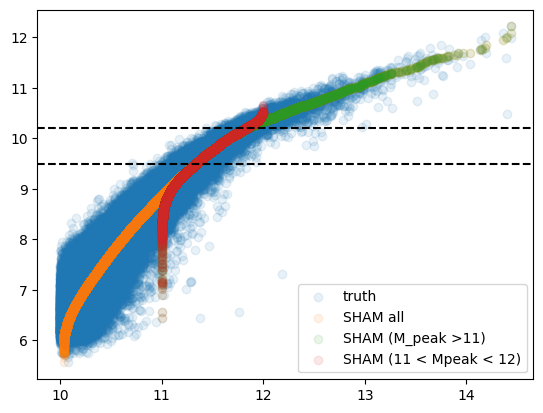

In [ ]:
# what does the SHMR look like

# compare with SHAM not cut
plt.scatter(
    np.log10(hydro_raw["mpeak"]),
    np.log10(hydro_raw["stellar_mass"]),
    alpha=0.1,
    label="truth",
)

x = np.log10(hydro_raw["mpeak"])
y_sham0 = qt(x, np.log10(hydro_raw["stellar_mass"]))
mpeak_mask0 = (x > 11) & (x < 12)

plt.scatter(x, y_sham0, alpha=0.1, label="SHAM all")

# compare with cut on low end only
x = np.log10(hydro_raw["mpeak"])
y = np.log10(hydro_raw["stellar_mass"])
y_sham1 = qt(x[x > 11], y[x > 11])
plt.scatter(x[x > 11], y_sham1, alpha=0.1, label="SHAM (M_peak >11)")

# compare with cut on low and high end
x = np.log10(hydro_raw["mpeak"])
y = np.log10(hydro_raw["stellar_mass"])
mask = (x > 11) & (x < 12)
y_sham2 = qt(x[mask], y[mask])
plt.scatter(x[mask], y_sham2, alpha=0.1, label="SHAM (11 < Mpeak < 12)")

plt.legend()

plt.axhline(9.5, c="k", ls="--")
plt.axhline(10.2, c="k", ls="--")


In [ ]:
# NOTE:
# Miss some galaxies but using the upper cut is the correct thing to do
# (1) No cut means constructing SHAM with low resolution
# (2) Cut on stellar mass means biasing result as cutting on dependent variable
# (3) Cut on DMO mpeak is OK even though we lose some due to completeness which we checked is small is the most principle thing to do

print(sum((y_sham0[mpeak_mask0] > 9.5) & (y_sham0[mpeak_mask0] < 10.2)))
print(sum((y_sham1 > 9.5) & (y_sham1 < 10.2)))
print(sum((y_sham2 > 9.5) & (y_sham2 < 10.2)))

4055
4051
4002
